# Compare SPM models

Three sections:
1. **Design matrices** — which columns are shared vs unique across models
2. **Group-level contrast maps** — side-by-side second-level T-maps
3. **Individual subject contrast maps** — per-subject comparison + cross-model correlation

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import plotting

## Configuration

Edit `MODEL_NAMES`, `CONTRAST_NAMES`, and `SUBJECTS_TO_PLOT` before running.

In [2]:
SPM_FIRST_LVL_ROOT = "/mnt/data/learning-habits/spm_format/outputs"
SPM_OUTPUTS_ROOT   = "/mnt/data/learning-habits/spm_outputs"

MODEL_NAMES = [
    "glm2_chosen_all_runs_scrubbed_2026-03-17-02-53",
    "glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed_2026-05-20-09-58",
    "glm2_chosen_Qval_2026-05-26-02-43"
]

# Fill in after running the "available contrasts" cell in Section 2
CONTRAST_NAMES = ["first_stim", "second_stim"]

# Section 3 only
SUBJECTS_TO_PLOT = ["sub-01", "sub-02", "sub-03"]

## Shared helpers

In [3]:
def model_label(name, all_names=None):
    """Strip timestamp suffix; keep date when stripping would produce duplicate labels."""
    stripped = re.sub(r'_\d{4}-\d{2}-\d{2}(-\d{2}-\d{2})?$', '', name)
    if all_names is not None:
        others_stripped = [re.sub(r'_\d{4}-\d{2}-\d{2}(-\d{2}-\d{2})?$', '', n) for n in all_names]
        if others_stripped.count(stripped) > 1:
            m = re.search(r'(\d{4}-\d{2}-\d{2})', name)
            return f"{stripped}_{m.group(1)}" if m else name
    return stripped


def clean_spm_colname(col):
    return col.replace('*bf(1)', '').replace('^1', '').strip()


def read_dm(dm_path, clean_colnames=True):
    colnames_file = dm_path.replace('design_matrix.csv', 'column_names.txt')
    with open(colnames_file) as f:
        colnames = [line.strip() for line in f]
    if clean_colnames:
        colnames = [clean_spm_colname(c) for c in colnames]
    return pd.read_csv(dm_path, header=None, names=colnames)


def read_dm_cols(dm_path, cols_to_load):
    """Read only the requested columns by position, skipping all others."""
    colnames_file = dm_path.replace('design_matrix.csv', 'column_names.txt')
    with open(colnames_file) as f:
        all_colnames = [clean_spm_colname(line.strip()) for line in f]
    col_index = {name: i for i, name in enumerate(all_colnames)}
    indices = [col_index[c] for c in cols_to_load if c in col_index]
    return pd.read_csv(dm_path, header=None, names=all_colnames, usecols=indices)


def find_contrast_dir(model_name, contrast_name):
    """Locate contrast directory, handling flat vs allruns/ layout."""
    for subdir in ["", "allruns"]:
        pattern = os.path.join(
            SPM_OUTPUTS_ROOT, model_name, subdir,
            f"contrast-*_{contrast_name}"
        )
        matches = glob.glob(pattern)
        if matches:
            return matches[0]
    return None


def get_second_lvl_tmap(model_name, contrast_name):
    """Find group T-map, handling flat, allruns/, and second-lvl/allruns/ layouts."""
    candidates = [
        os.path.join(SPM_OUTPUTS_ROOT, model_name, "second-lvl", contrast_name, "spmT_0001.nii"),
        os.path.join(SPM_OUTPUTS_ROOT, model_name, "second-lvl", "allruns", contrast_name, "spmT_0001.nii"),
        os.path.join(SPM_OUTPUTS_ROOT, model_name, "allruns", "second-lvl", contrast_name, "spmT_0001.nii"),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return None


def list_second_lvl_contrasts(model_name):
    """Return contrast names available at second level, handling nested layouts."""
    contrasts = set()
    second_lvl_dir = os.path.join(SPM_OUTPUTS_ROOT, model_name, "second-lvl")
    if not os.path.isdir(second_lvl_dir):
        return contrasts
    for entry in os.listdir(second_lvl_dir):
        entry_path = os.path.join(second_lvl_dir, entry)
        if not os.path.isdir(entry_path):
            continue
        # If this looks like a contrast dir (contains spmT), add it directly
        if os.path.exists(os.path.join(entry_path, "spmT_0001.nii")):
            contrasts.add(entry)
        else:
            # It's a grouping dir (allruns, session-01, …); look one level deeper
            for sub_entry in os.listdir(entry_path):
                sub_path = os.path.join(entry_path, sub_entry)
                if os.path.isdir(sub_path) and os.path.exists(os.path.join(sub_path, "spmT_0001.nii")):
                    contrasts.add(sub_entry)
    return contrasts


def get_subject_contrast(model_name, contrast_name, subject_id):
    cdir = find_contrast_dir(model_name, contrast_name)
    if cdir is None:
        return None
    p = os.path.join(cdir, f"{subject_id}_desc-{contrast_name}_con.nii")
    return p if os.path.exists(p) else None


LABELS = [model_label(m, MODEL_NAMES) for m in MODEL_NAMES]
print("Models:", LABELS)

Models: ['glm2_chosen_all_runs_scrubbed', 'glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed', 'glm2_chosen_Qval']


---
## Section 1 — Design Matrix Comparison

In [4]:
CONFOUND_RE = re.compile(r'^Sn\(\d+\) R\d+$')

def is_confound(col):
    return bool(CONFOUND_RE.match(col))

# Load all subjects' columns per model, split into task and confound sets.
# Task columns use the union across subjects (they should be identical per subject
# within a model). Confound columns are collected per subject to track scrubbing counts.
model_task_cols         = {}   # model → set of task column names (union across subjects)
model_subject_task_cols = {}   # model → {subject: set of task column names}
model_confound_counts   = {}   # model → {subject: n_confound_cols}

for model in MODEL_NAMES:
    txt_paths = sorted(
        glob.glob(os.path.join(SPM_FIRST_LVL_ROOT, model, "sub-*", "*_column_names.txt"))
    )
    if not txt_paths:
        print(f"WARNING: no column_names.txt found for {model}")
        model_task_cols[model] = set()
        model_subject_task_cols[model] = {}
        model_confound_counts[model] = {}
        continue

    task_union = set()
    subject_task_cols = {}
    confound_counts = {}
    for p in txt_paths:
        sub = re.search(r'(sub-\d+)', p).group(1)
        with open(p) as f:
            cols = [clean_spm_colname(line.strip()) for line in f]
        task_cols = set(c for c in cols if not is_confound(c))
        task_union.update(task_cols)
        subject_task_cols[sub] = task_cols
        confound_counts[sub] = sum(1 for c in cols if is_confound(c))

    model_task_cols[model] = task_union
    model_subject_task_cols[model] = subject_task_cols
    model_confound_counts[model] = confound_counts
    label = model_label(model, MODEL_NAMES)
    n_subs = len(confound_counts)
    confound_vals = list(confound_counts.values())
    print(f"{label}: {len(task_union)} task cols | "
          f"confounds/subject: min={min(confound_vals)} max={max(confound_vals)} "
          f"mean={np.mean(confound_vals):.1f}  ({n_subs} subjects)")

glm2_chosen_all_runs_scrubbed: 29 task cols | confounds/subject: min=78 max=321 mean=140.1  (60 subjects)
glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed: 29 task cols | confounds/subject: min=78 max=321 mean=140.1  (60 subjects)
glm2_chosen_Qval: 26 task cols | confounds/subject: min=78 max=321 mean=140.1  (60 subjects)


In [5]:
# --- Task column presence table ---
all_task_cols = sorted(set.union(*model_task_cols.values()))
presence = pd.DataFrame(
    {model_label(m, MODEL_NAMES): [c in model_task_cols[m] for c in all_task_cols] for m in MODEL_NAMES},
    index=all_task_cols,
)

n_models = len(MODEL_NAMES)
row_sums = presence.sum(axis=1)

in_all  = presence[row_sums == n_models]
in_some = presence[(row_sums > 1) & (row_sums < n_models)]
in_one  = presence[row_sums == 1]

print(f"Task columns in ALL {n_models} models ({len(in_all)}):")
print(in_all.index.tolist())

print(f"\nTask columns in SOME models ({len(in_some)}):")
print(in_some.index.tolist())

print(f"\nTask columns unique to ONE model ({len(in_one)}):")
for col in in_one.index:
    owner = in_one.loc[col][in_one.loc[col]].index[0]
    print(f"  {col!r}  →  {owner}")

Task columns in ALL 3 models (26):
['Sn(1) constant', 'Sn(1) first_stim', 'Sn(1) nresp_screen', 'Sn(1) points_feedback', 'Sn(1) purple_frame', 'Sn(1) response', 'Sn(1) second_stim', 'Sn(1) second_stim_nresp', 'Sn(1) second_stimxQval_chosen', 'Sn(2) constant', 'Sn(2) first_stim', 'Sn(2) nresp_screen', 'Sn(2) points_feedback', 'Sn(2) purple_frame', 'Sn(2) response', 'Sn(2) second_stim', 'Sn(2) second_stim_nresp', 'Sn(2) second_stimxQval_chosen', 'Sn(3) constant', 'Sn(3) first_stim', 'Sn(3) nresp_screen', 'Sn(3) purple_frame', 'Sn(3) response', 'Sn(3) second_stim', 'Sn(3) second_stim_nresp', 'Sn(3) second_stimxQval_chosen']

Task columns in SOME models (3):
['Sn(1) second_stimxHval_chosen', 'Sn(2) second_stimxHval_chosen', 'Sn(3) second_stimxHval_chosen']

Task columns unique to ONE model (0):


In [6]:
# Styled presence table — green = present, light grey = absent
def style_presence(v):
    return "background-color: #c6efce; color: #276221" if v else "background-color: #f2f2f2; color: #aaa"

presence.style.applymap(style_presence).set_caption("Column presence across models")

/tmp/ipykernel_7396/3208385999.py:5: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  presence.style.applymap(style_presence).set_caption("Column presence across models")


,glm2_chosen_all_runs_scrubbed,glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed,glm2_chosen_Qval
Sn(1) constant,True,True,True
Sn(1) first_stim,True,True,True
Sn(1) nresp_screen,True,True,True
Sn(1) points_feedback,True,True,True
Sn(1) purple_frame,True,True,True
Sn(1) response,True,True,True
Sn(1) second_stim,True,True,True
Sn(1) second_stim_nresp,True,True,True
Sn(1) second_stimxHval_chosen,True,True,False
Sn(1) second_stimxQval_chosen,True,True,True


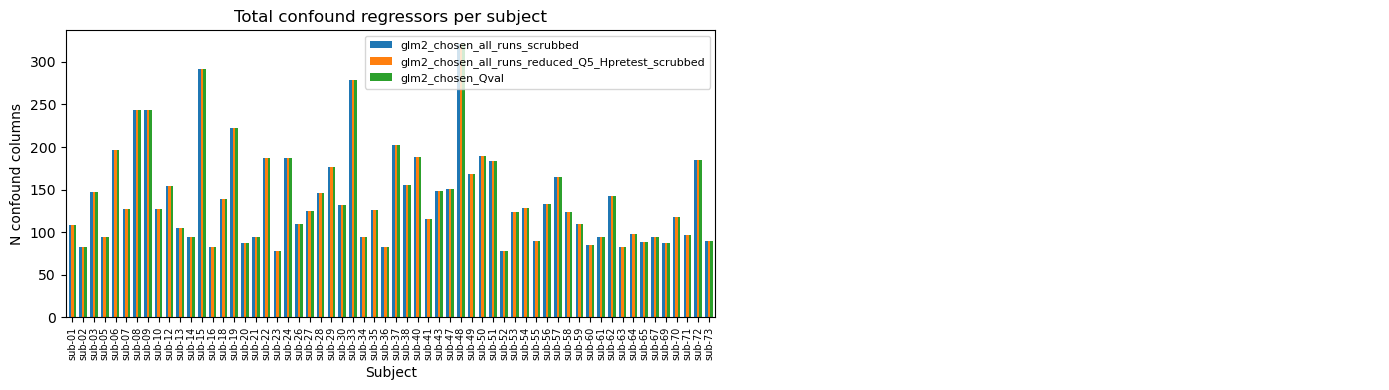

In [7]:
# --- Confound column comparison across subjects ---
# Build a DataFrame: rows = subjects, columns = models, values = total confound regressors.
# The first 6 per session are fixed motion params; the remainder are scrubbing regressors.
all_subs = sorted(set.union(*[set(v.keys()) for v in model_confound_counts.values()]))
confound_df = pd.DataFrame(
    {model_label(m, MODEL_NAMES): [model_confound_counts[m].get(s, np.nan) for s in all_subs]
     for m in MODEL_NAMES},
    index=all_subs,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: per-subject bar chart
confound_df.plot(kind="bar", ax=axes[0], width=0.7)
axes[0].set_title("Total confound regressors per subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("N confound columns")
axes[0].tick_params(axis='x', labelrotation=90, labelsize=7)
axes[0].legend(fontsize=8)

# Right: difference between models (only meaningful when comparing exactly 2)
if n_models == 2:
    labels = [model_label(m, MODEL_NAMES) for m in MODEL_NAMES]
    diff = confound_df[labels[0]] - confound_df[labels[1]]
    colors = ["#d62728" if v > 0 else "#1f77b4" if v < 0 else "#aaa" for v in diff]
    axes[1].bar(all_subs, diff, color=colors)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"Confound count difference\n({labels[0]} − {labels[1]})")
    axes[1].set_xlabel("Subject")
    axes[1].set_ylabel("Δ confound columns")
    axes[1].tick_params(axis='x', labelrotation=90, labelsize=7)
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()

### Non-identical columns: model-level vs subject-specific?

In [8]:
# --- Task regressors: are non-identical columns model-level or subject-specific? ---
non_identical_task = sorted(in_some.index.union(in_one.index).tolist())

if not non_identical_task:
    print("All task columns are identical across models.")
else:
    print("Non-identical task columns and their subject-level consistency:\n")
    rows = []
    for col in non_identical_task:
        row = {"column": col}
        for model in MODEL_NAMES:
            sub_cols = model_subject_task_cols[model]
            n_total = len(sub_cols)
            n_present = sum(1 for sc in sub_cols.values() if col in sc)
            if n_present == 0:
                status = "absent in all"
            elif n_present == n_total:
                status = "present in all"
            else:
                status = f"present in {n_present}/{n_total} subjects  ← subject-specific"
            row[model_label(model, MODEL_NAMES)] = status
        rows.append(row)
    df_task_diff = pd.DataFrame(rows).set_index("column")
    print(df_task_diff.to_string())

# --- Confounds: are differences consistent or subject-specific? ---
print("\n\nConfound count differences across subjects:")
all_subs_conf = sorted(set.union(*[set(v.keys()) for v in model_confound_counts.values()]))
confound_df_full = pd.DataFrame(
    {model_label(m, MODEL_NAMES): [model_confound_counts[m].get(s, np.nan) for s in all_subs_conf]
     for m in MODEL_NAMES},
    index=all_subs_conf,
)

if n_models >= 2:
    labels = [model_label(m, MODEL_NAMES) for m in MODEL_NAMES]
    ref_label = labels[0]
    diffs = confound_df_full.subtract(confound_df_full[ref_label], axis=0).drop(columns=ref_label)
    differing_subs = diffs[(diffs != 0).any(axis=1)]

    if differing_subs.empty:
        print("Confound counts are identical for all subjects across all models.")
    else:
        for col in diffs.columns:
            ud = diffs[col].dropna().unique()
            n_diff_subs = int((diffs[col] != 0).sum())
            if len(ud) == 1 and ud[0] == 0:
                print(f"  {ref_label} vs {col}: identical for all subjects")
            elif len(ud) == 1:
                print(f"  {ref_label} vs {col}: consistent offset of {ud[0]:+.0f} for all subjects  ← model-level")
            else:
                print(f"  {ref_label} vs {col}: varies across subjects ({n_diff_subs} subjects differ)  ← subject-specific")
                print(differing_subs[[col]].rename(columns={col: "Δ"}).to_string())
else:
    print("Only one model — no comparison possible.")

Non-identical task columns and their subject-level consistency:

                              glm2_chosen_all_runs_scrubbed glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed glm2_chosen_Qval
column                                                                                                                        
Sn(1) second_stimxHval_chosen                present in all                                    present in all    absent in all
Sn(2) second_stimxHval_chosen                present in all                                    present in all    absent in all
Sn(3) second_stimxHval_chosen                present in all                                    present in all    absent in all


Confound count differences across subjects:
Confound counts are identical for all subjects across all models.


### Value comparison for shared columns

In [9]:
# Load full DMs for all common subjects once — reused by the value comparison cell below
shared_cols = sorted(in_all.index)  # task columns shared across all models

sub_sets = [
    set(re.search(r'(sub-\d+)', p).group(1)
        for p in glob.glob(os.path.join(SPM_FIRST_LVL_ROOT, m, "sub-*", "*_design_matrix.csv")))
    for m in MODEL_NAMES
]
common_subs = sorted(set.intersection(*sub_sets))

dm_cache = {}  # dm_cache[model][sub] → full DataFrame
for model in MODEL_NAMES:
    dm_cache[model] = {}
    for sub in common_subs:
        dm_path = os.path.join(SPM_FIRST_LVL_ROOT, model, sub, f"{sub}_design_matrix.csv")
        if os.path.exists(dm_path):
            dm_cache[model][sub] = read_dm(dm_path)

print(f"Cached all columns for {len(common_subs)} subjects × {len(MODEL_NAMES)} models")

Cached all columns for 60 subjects × 3 models


In [10]:
from scipy.stats import pearsonr

print(f"Comparing columns across {len(common_subs)} subjects\n")

col_stats = {}  # col → list of (mad, r)

for sub in common_subs:
    ref_dm = dm_cache[MODEL_NAMES[0]].get(sub)
    if ref_dm is None:
        continue
    for other_model in MODEL_NAMES[1:]:
        other_dm = dm_cache[other_model].get(sub)
        if other_dm is None or len(ref_dm) != len(other_dm):
            continue
        # Compare all columns present in both models for this subject
        cols_to_compare = set(ref_dm.columns) & set(other_dm.columns)
        for col in cols_to_compare:
            a = ref_dm[col].values.astype(float)
            b = other_dm[col].values.astype(float)
            mad = np.mean(np.abs(a - b))
            r = pearsonr(a, b)[0] if np.std(a) > 0 and np.std(b) > 0 else (1.0 if np.allclose(a, b) else np.nan)
            col_stats.setdefault(col, []).append((mad, r))

rows = []
for col, entries in col_stats.items():
    mads, rs = zip(*entries)
    rows.append({
        "column": col,
        "type": "confound" if is_confound(col) else "task",
        "mean_r": np.nanmean(rs),
        "min_r":  np.nanmin(rs),
        "mean_abs_diff": np.mean(mads),
        "max_abs_diff":  np.max(mads),
        "n_subjects": len(entries),
    })

val_df = (pd.DataFrame(rows)
            .set_index("column")
            .sort_values(["type", "mean_r"]))

for col_type in ["task", "confound"]:
    subset = val_df[val_df["type"] == col_type].drop(columns="type")
    differing  = subset[subset["mean_abs_diff"] > 1e-8]
    identical  = subset[subset["mean_abs_diff"] <= 1e-8]
    print(f"── {col_type.upper()} columns ──")
    print(f"  identical: {len(identical)}   differing: {len(differing)}")
    if not differing.empty:
        print(differing.sort_values("mean_r").to_string(float_format=lambda x: f"{x:.4f}"))
    print()

Comparing columns across 60 subjects

── TASK columns ──
  identical: 23   differing: 6
                               mean_r   min_r  mean_abs_diff  max_abs_diff  n_subjects
column                                                                                
Sn(1) second_stimxHval_chosen  0.3606 -0.0734         0.0219        0.0297          60
Sn(2) second_stimxHval_chosen  0.6676  0.0471         0.0116        0.0192          60
Sn(3) second_stimxHval_chosen  0.6994  0.1992         0.0196        0.0345          60
Sn(1) second_stimxQval_chosen  0.9962  0.9254         0.0005        0.0051         120
Sn(3) second_stimxQval_chosen  0.9999  0.9972         0.0002        0.0023         120
Sn(2) second_stimxQval_chosen  0.9999  0.9964         0.0001        0.0014         120

── CONFOUND columns ──
  identical: 351   differing: 0



In [11]:
MODEL_NAMES

['glm2_chosen_all_runs_scrubbed_2026-03-17-02-53',
 'glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed_2026-05-20-09-58',
 'glm2_chosen_Qval_2026-05-26-02-43']

In [12]:
dm_cache[MODEL_NAMES[2]]['sub-01'].head()

,Sn(1) first_stim,Sn(1) second_stim,Sn(1) second_stimxQval_chosen,Sn(1) response,Sn(1) purple_frame,Sn(1) points_feedback,Sn(1) nresp_screen,Sn(1) second_stim_nresp,Sn(1) R1,Sn(1) R2,...,Sn(3) R44,Sn(3) R45,Sn(3) R46,Sn(3) R47,Sn(3) R48,Sn(3) R49,Sn(3) R50,Sn(1) constant,Sn(2) constant,Sn(3) constant
0,0.001113,8.323413e-08,-1.542373e-07,0.000000,0.000000,0.000000,0.0,0.0,27.047941,-0.006210,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
1,0.116290,4.881226e-02,-9.045174e-02,0.021371,0.007869,0.001113,0.0,0.0,-7.192166,-0.004720,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
2,0.211977,2.039137e-01,-3.778630e-01,0.184546,0.100375,0.126078,0.0,0.0,13.395655,-0.004550,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
3,0.129077,1.684038e-01,-3.120613e-01,0.182993,0.111155,0.242331,0.0,0.0,-13.846014,-0.004734,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
4,0.041829,6.926567e-02,-1.283530e-01,0.083434,0.053753,0.151323,0.0,0.0,-18.133802,-0.004501,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0


In [13]:
dm_cache[MODEL_NAMES[0]]['sub-01'].head()


,Sn(1) first_stim,Sn(1) second_stim,Sn(1) second_stimxQval_chosen,Sn(1) second_stimxHval_chosen,Sn(1) response,Sn(1) purple_frame,Sn(1) points_feedback,Sn(1) nresp_screen,Sn(1) second_stim_nresp,Sn(1) R1,...,Sn(3) R44,Sn(3) R45,Sn(3) R46,Sn(3) R47,Sn(3) R48,Sn(3) R49,Sn(3) R50,Sn(1) constant,Sn(2) constant,Sn(3) constant
0,0.001113,8.323413e-08,-1.542373e-07,-1.212862e-07,0.000000,0.000000,0.000000,0.0,0.0,27.047941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
1,0.116290,4.881226e-02,-9.045174e-02,-7.112774e-02,0.021371,0.007869,0.001113,0.0,0.0,-7.192166,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
2,0.211977,2.039137e-01,-3.778630e-01,-2.971368e-01,0.184546,0.100375,0.126078,0.0,0.0,13.395655,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
3,0.129077,1.684038e-01,-3.120613e-01,-2.453929e-01,0.182993,0.111155,0.242331,0.0,0.0,-13.846014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
4,0.041829,6.926567e-02,-1.283530e-01,-1.009318e-01,0.083434,0.053753,0.151323,0.0,0.0,-18.133802,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0


---
## Section 2 — Group-Level Contrast Maps

In [34]:
available_contrasts = {}
for model in MODEL_NAMES:
    available_contrasts[model] = list_second_lvl_contrasts(model)
    print(f"{model_label(model, MODEL_NAMES)}: {sorted(available_contrasts[model])}")

glm2_chosen_all_runs_scrubbed: ['first_stim', 'purple_frame', 'response', 'second_stim', 'second_stimxhval_chosen', 'second_stimxqval_chosen']
glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed: ['first_stim', 'purple_frame', 'response', 'second_stim', 'second_stimxhval_chosen', 'second_stimxqval_chosen']
glm2_chosen_Qval: ['first_stim', 'purple_frame', 'response', 'second_stim', 'second_stimxqval_chosen']


In [35]:
# Presence table for second-level contrasts
all_2nd_contrasts = sorted(set.union(*available_contrasts.values()))
contrast_presence = pd.DataFrame(
    {model_label(m): [c in available_contrasts[m] for c in all_2nd_contrasts] for m in MODEL_NAMES},
    index=all_2nd_contrasts,
)
contrast_presence.style.applymap(style_presence).set_caption("Available second-level contrasts")

/tmp/ipykernel_4356/2632340627.py:7: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  contrast_presence.style.applymap(style_presence).set_caption("Available second-level contrasts")


,glm2_chosen_all_runs_scrubbed,glm2_chosen_all_runs_reduced_Q5_Hpretest_scrubbed,glm2_chosen_Qval
first_stim,True,True,True
purple_frame,True,True,True
response,True,True,True
second_stim,True,True,True
second_stimxhval_chosen,True,True,False
second_stimxqval_chosen,True,True,True


In [39]:
contrasts_to_compare = [
    'second_stim',
    'second_stimxqval_chosen'
]

/tmp/ipykernel_4356/58696971.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


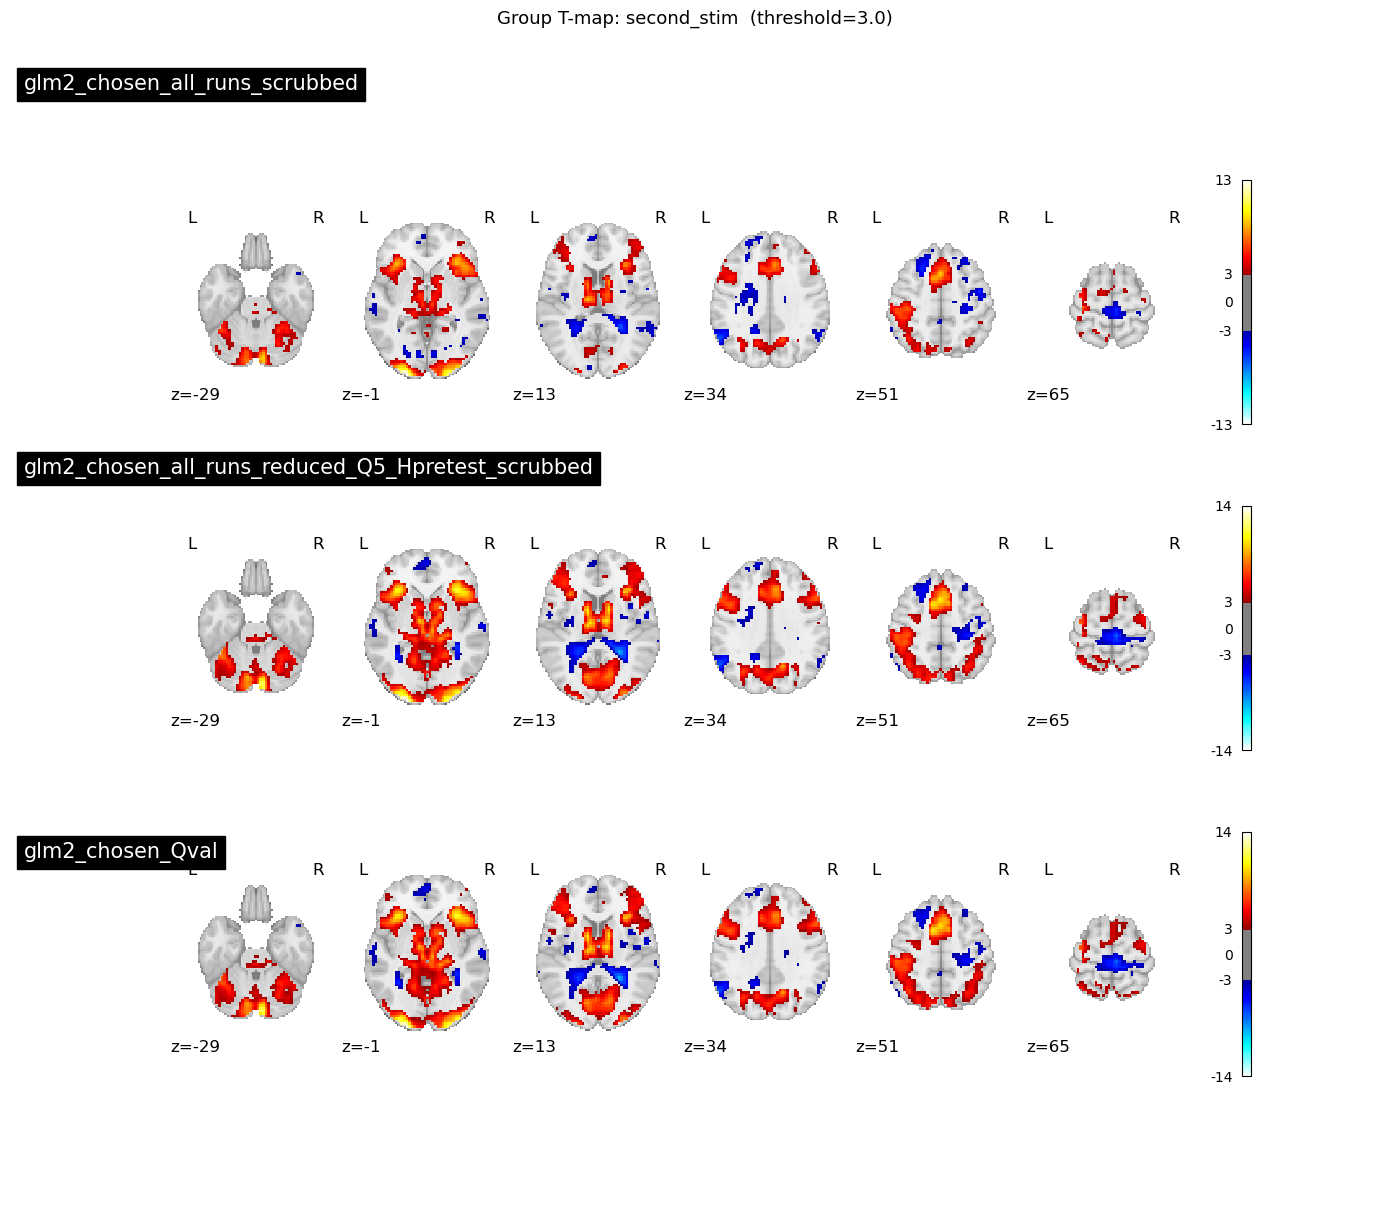

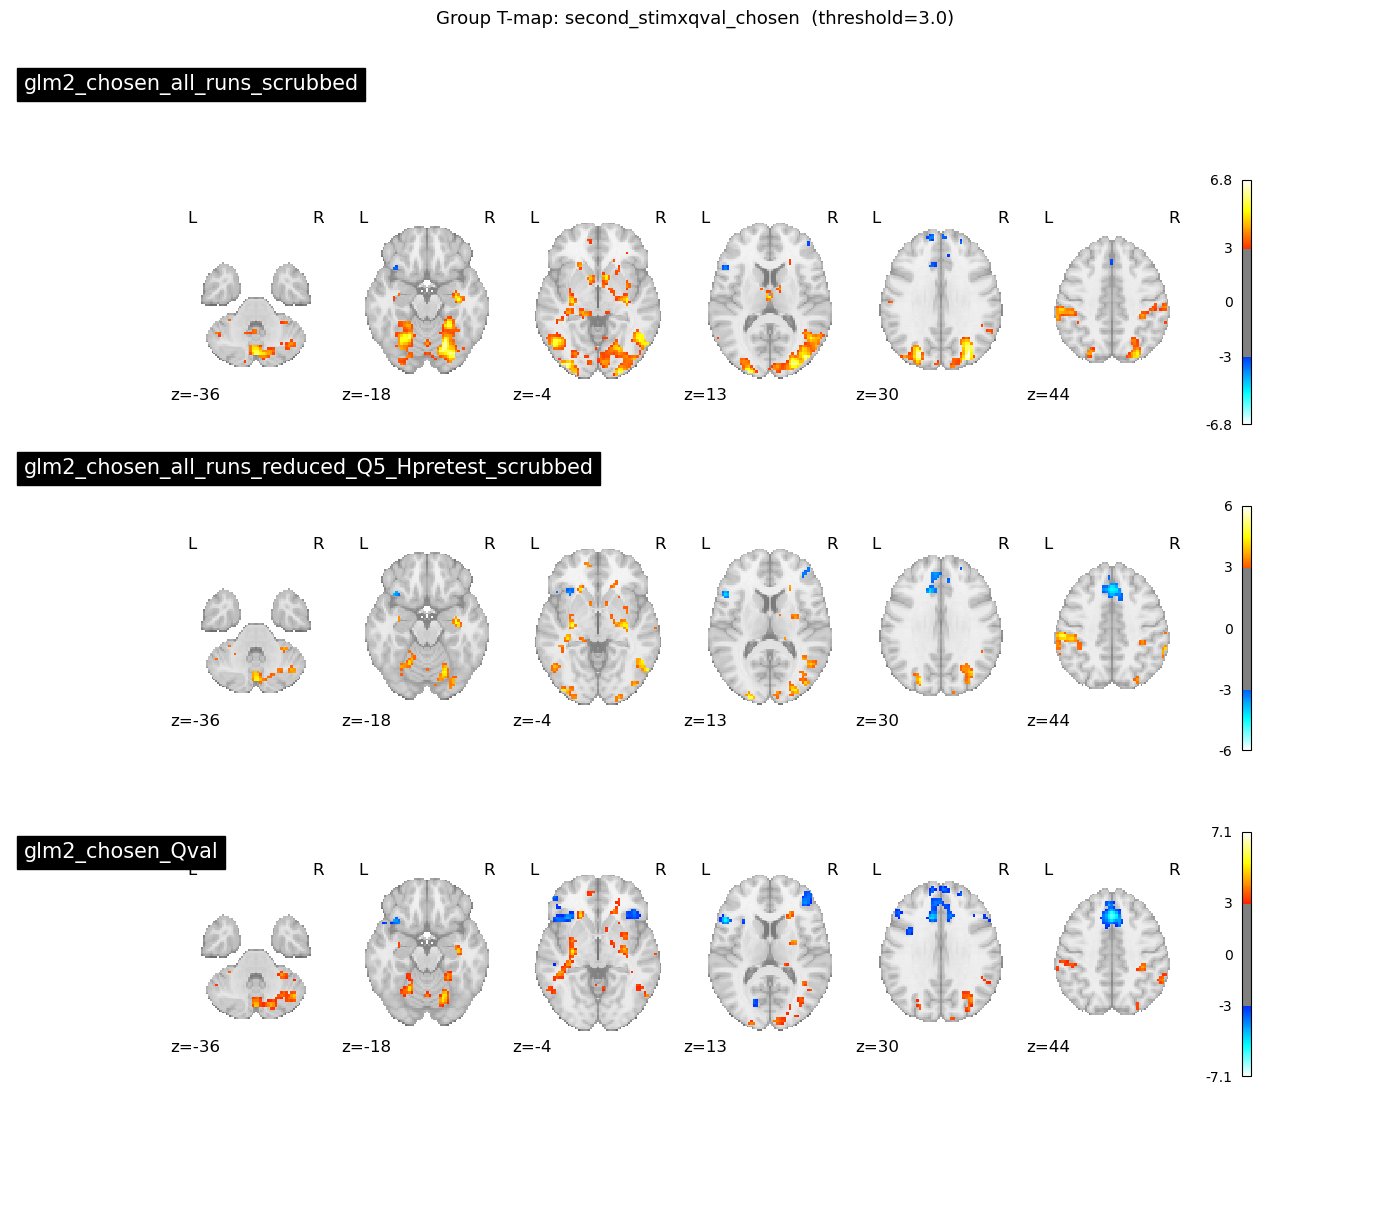

In [40]:
STAT_THRESHOLD = 3.0  # adjust as needed

for contrast in contrasts_to_compare:
    tmap_paths = [get_second_lvl_tmap(m, contrast) for m in MODEL_NAMES]
    available = [(label, p) for label, p in zip(LABELS, tmap_paths) if p is not None]
    missing   = [label for label, p in zip(LABELS, tmap_paths) if p is None]

    if missing:
        print(f"[{contrast}] No second-level map found for: {missing}")
    if not available:
        continue

    # Derive z-cuts from the first available map so all panels share the same slices
    cut_coords = plotting.find_cut_slices(available[0][1], direction='z', n_cuts=6)

    fig, axes = plt.subplots(len(available), 1, figsize=(14, 4 * len(available)))
    if len(available) == 1:
        axes = [axes]

    for ax, (label, tmap) in zip(axes, available):
        plotting.plot_stat_map(
            tmap,
            threshold=STAT_THRESHOLD,
            display_mode="z",
            cut_coords=cut_coords,
            colorbar=True,
            title=label,
            axes=ax,
        )

    fig.suptitle(f"Group T-map: {contrast}  (threshold={STAT_THRESHOLD})", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

---
## Section 3 — Individual Subject Contrast Maps

In [ ]:
# Plot subject-level contrast maps: rows = subjects, columns = models
SUBJECT_THRESHOLD = 2.0  # lower threshold for single-subject maps

for contrast in CONTRAST_NAMES:
    n_rows = len(SUBJECTS_TO_PLOT)
    fig, axes = plt.subplots(n_rows, n_models, figsize=(6 * n_models, 4 * n_rows))
    if n_rows == 1:
        axes = [axes]
    if n_models == 1:
        axes = [[row] for row in axes]

    for row_idx, subject in enumerate(SUBJECTS_TO_PLOT):
        for col_idx, (model, label) in enumerate(zip(MODEL_NAMES, LABELS)):
            ax = axes[row_idx][col_idx]
            con_path = get_subject_contrast(model, contrast, subject)
            if con_path is None:
                ax.set_title(f"{label}\n(not found)", fontsize=9)
                ax.axis('off')
                continue
            plotting.plot_stat_map(
                con_path,
                threshold=SUBJECT_THRESHOLD,
                display_mode="z",
                cut_coords=5,
                colorbar=True,
                title=label if row_idx == 0 else "",
                axes=ax,
            )
            if col_idx == 0:
                ax.set_ylabel(subject, fontsize=10)

    fig.suptitle(f"Individual contrast maps: {contrast}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
# Cross-model correlation of contrast maps across subjects
# For each contrast: compute voxel-wise Pearson r between each pair of models,
# averaged across SUBJECTS_TO_PLOT.
import seaborn as sns
from scipy.stats import pearsonr

for contrast in CONTRAST_NAMES:
    # Collect flat voxel arrays per model (subjects × voxels)
    model_vecs = {}  # label → list of 1-D arrays
    for model, label in zip(MODEL_NAMES, LABELS):
        vecs = []
        for subject in SUBJECTS_TO_PLOT:
            p = get_subject_contrast(model, contrast, subject)
            if p is not None:
                img = nib.load(p)
                data = img.get_fdata()
                mask = np.isfinite(data) & (data != 0)
                vecs.append(data[mask].ravel())
        model_vecs[label] = vecs

    # Per-subject pairwise correlations, then average
    n = len(LABELS)
    corr_matrix = np.full((n, n), np.nan)
    for i, label_i in enumerate(LABELS):
        for j, label_j in enumerate(LABELS):
            rs = []
            for sub_idx in range(len(SUBJECTS_TO_PLOT)):
                vi = model_vecs[label_i]
                vj = model_vecs[label_j]
                if sub_idx < len(vi) and sub_idx < len(vj) and len(vi[sub_idx]) == len(vj[sub_idx]):
                    # align to common non-zero mask
                    mask = np.isfinite(vi[sub_idx]) & np.isfinite(vj[sub_idx])
                    if mask.sum() > 10:
                        r, _ = pearsonr(vi[sub_idx][mask], vj[sub_idx][mask])
                        rs.append(r)
            if rs:
                corr_matrix[i, j] = np.mean(rs)

    fig, ax = plt.subplots(figsize=(max(4, n * 1.5), max(3, n * 1.5)))
    sns.heatmap(
        corr_matrix,
        xticklabels=LABELS, yticklabels=LABELS,
        annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=-1, vmax=1, ax=ax,
    )
    ax.set_title(f"Mean cross-model voxel correlation: {contrast}\n(averaged over {len(SUBJECTS_TO_PLOT)} subjects)")
    plt.tight_layout()
    plt.show()